# Tutorial: Visualizing Orbital Probability Clouds with Real MCMC Traces

This tutorial demonstrates how to load real MCMC traces into `orbcloud` to visualize 3D orbital probability clouds.

### Customization for different datasets:
- **Star Data**: You can customize the central star's properties (name, mass, and spectral type color) in the `SystemEnsemble` constructor.
- **Orientation**: In this tutorial, the inclination ($i$) and longitude of ascending node ($\Omega$) are fixed to $0^\circ$ for all planets, representing a coplanar, face-on projection (Z=0 plane).
- **Custom Files**: Simply change the `trace_path` variable and rename `planet_prefix` to match your own target system.

In [1]:
import sys
import os

# Ensure orbcloud and the trace loader helper are in the Python search path
sys.path.insert(0, os.path.abspath('../../src'))
sys.path.insert(0, os.path.abspath('.'))

### Nominal Orbit Parameter Estimation: Mean vs. Mode (KDE)
For MCMC parameter posteriors, the distributions for eccentricity ($e$) and argument of periastron ($\omega$) are often skewed or asymmetric (e.g., eccentricity peaks close to 0). In such cases, the mean or median parameter values may represent a less probable orbital state.

To resolve this, we use a 1D **Kernel Density Estimation (KDE)** to find the **mode** (the highest peak in the probability density) for the nominal eccentricity ($e$) and argument of periastron ($\omega$). The code below defines this function. Our backend helper `trace_loader` uses this function internally to load the traces.

In [2]:
import numpy as np
from scipy.stats import gaussian_kde

def get_posterior_mode_kde(trace, param_name):
    """
    Finds the mode of a parameter posterior distribution using KDE.
    Allows customization of bandwidth parameter (bw_method) if needed.
    """
    if param_name not in trace.posterior.data_vars:
        return np.nan
    samples = trace.posterior[param_name].values.flatten()
    if len(np.unique(samples)) < 2:
        return samples[0] if len(samples) > 0 else np.nan
    
    # Standard Gaussian KDE. You can customize 'bw_method' (e.g., bw_method=0.2) if needed.
    kde = gaussian_kde(samples, bw_method='silverman')
    x_range = np.linspace(samples.min(), samples.max(), 1000)
    y_density = kde(x_range)
    return x_range[np.argmax(y_density)]

# Section 1: The 4-Planet System

We initialize the central star for a 4-planet system. You can modify the mass and spectral type below to match any target star.

In [3]:
import matplotlib.pyplot as plt
from orbcloud import SystemEnsemble
from trace_loader import load_real_trace_to_system

# 1. Initialize the system. Customize these parameters for other stars!
system_4p = SystemEnsemble(
    star_id='barnard',       
    star_name="Barnard's Star",
    star_mass=0.162,         # Star mass in Solar Masses
    star_type='M'            # Spectral type: 'O', 'B', 'A', 'F', 'G', 'K', 'M'
)

# 2. Load the 4-planet MCMC trace data
load_real_trace_to_system(
    system_4p,
    trace_path="trace_emxr_4p.nc",
    num_samples=1000,        # Downsample to 1,000 MCMC samples for smooth plotting speed
    i_deg=0.0,               # Fixed inclination
    Omega_deg=0.0            # Fixed longitude of ascending node
)

print(f"\nInitialized {system_4p.star_props['name']} (Mass: {system_4p.m_star} M_sun)")

Loading trace from trace_emxr_4p.nc...
Found 4 planets with indices: [1, 2, 3, 4]
Added Planet b: P=3.1539 d, e=0.0153 (mode)
Added Planet c: P=2.3400 d, e=0.1324 (mode)
Added Planet d: P=4.1245 d, e=0.1866 (mode)
Added Planet e: P=6.7408 d, e=0.0262 (mode)

Initialized Barnard's Star (Mass: 0.162 M_sun)


In [4]:
# Swap the data of 'Planet c' and 'Planet d' in the system ensemble
if 'Planet c' in system_4p.planets and 'Planet d' in system_4p.planets:
    print("Swapping Planet c and Planet d data...")
    temp_c = system_4p.planets['Planet c']
    system_4p.planets['Planet c'] = system_4p.planets['Planet d']
    system_4p.planets['Planet d'] = temp_c

Swapping Planet c and Planet d data...


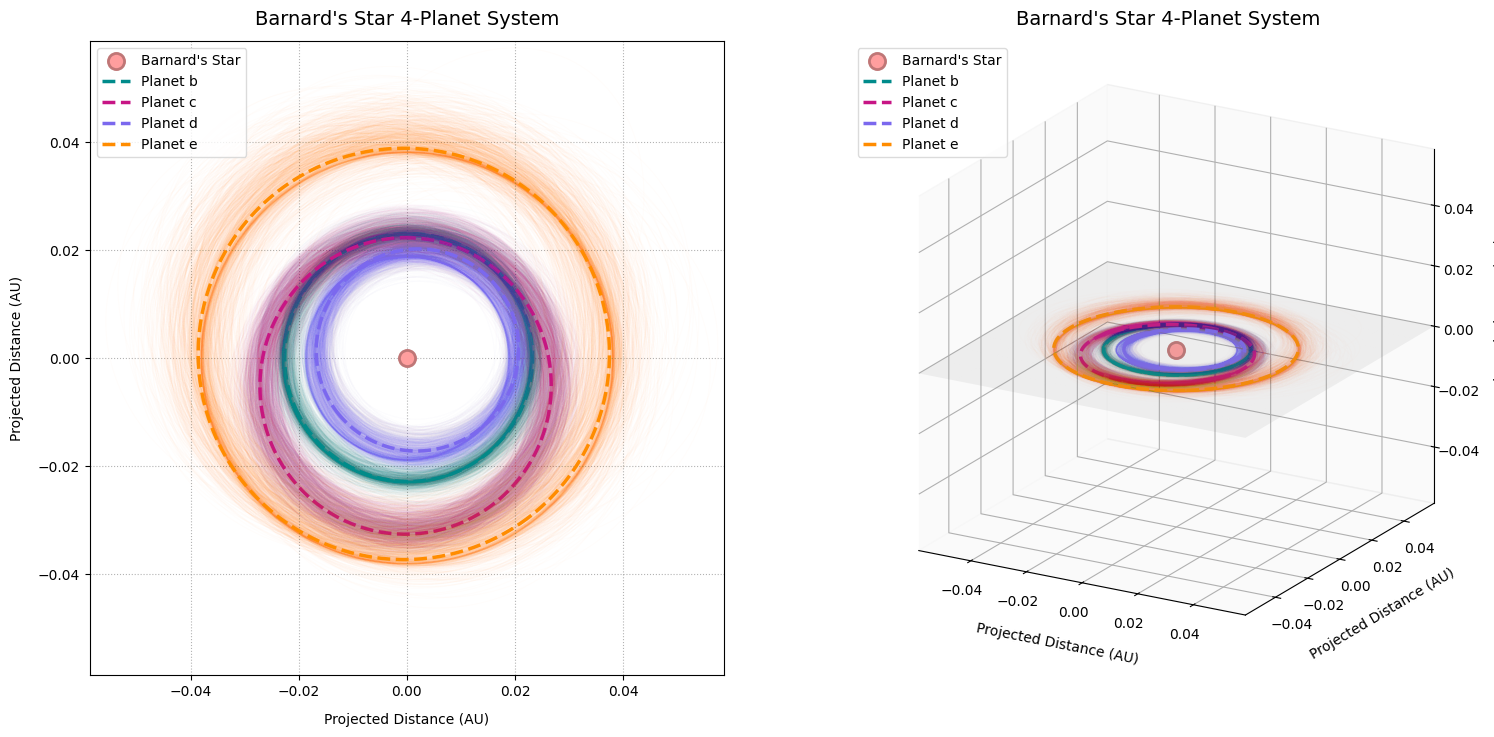

In [5]:
# Set up the figure for side-by-side plotting
fig = plt.figure(figsize=(18, 9), facecolor='white')
ax2d = fig.add_subplot(121, facecolor='white')
ax3d = fig.add_subplot(122, projection='3d', facecolor='white')

# Plot the system clouds
system_4p.plot_system(
    ax=[ax2d, ax3d],
    dimension='both',
    alpha_2d=0.015,
    alpha_3d=0.008,
    show_reference_plane=True
)

ax2d.set_title("Barnard's Star 4-Planet System", fontsize=14, pad=12)
ax3d.set_title("Barnard's Star 4-Planet System", fontsize=14, pad=12)

plt.show()

# Section 2: The 3-Planet System

Here we load the alternative 3-planet dataset for the same star.

In [9]:
# 1. Initialize the system ensemble
system_3p = SystemEnsemble(
    star_id='barnard',
    star_name="Barnard's Star",
    star_mass=0.162,
    star_type='M'
)

# 2. Load the 3-planet MCMC trace data
load_real_trace_to_system(
    system_3p,
    trace_path="trace_all_3p.nc",
    num_samples=1000,
    i_deg=0.0,
    Omega_deg=0.0
)

Loading trace from trace_all_3p.nc...
Found 3 planets with indices: [1, 2, 3]
Added Planet b: P=3.1538 d, e=0.0138 (mode)
Added Planet c: P=2.3401 d, e=0.0236 (mode)
Added Planet d: P=4.1235 d, e=0.0219 (mode)


In [10]:
# Swap the data of 'Planet c' and 'Planet d' in the system ensemble
if 'Planet c' in system_3p.planets and 'Planet d' in system_3p.planets:
    print("Swapping Planet c and Planet d data...")
    temp_c = system_3p.planets['Planet c']
    system_3p.planets['Planet c'] = system_3p.planets['Planet d']
    system_3p.planets['Planet d'] = temp_c

Swapping Planet c and Planet d data...


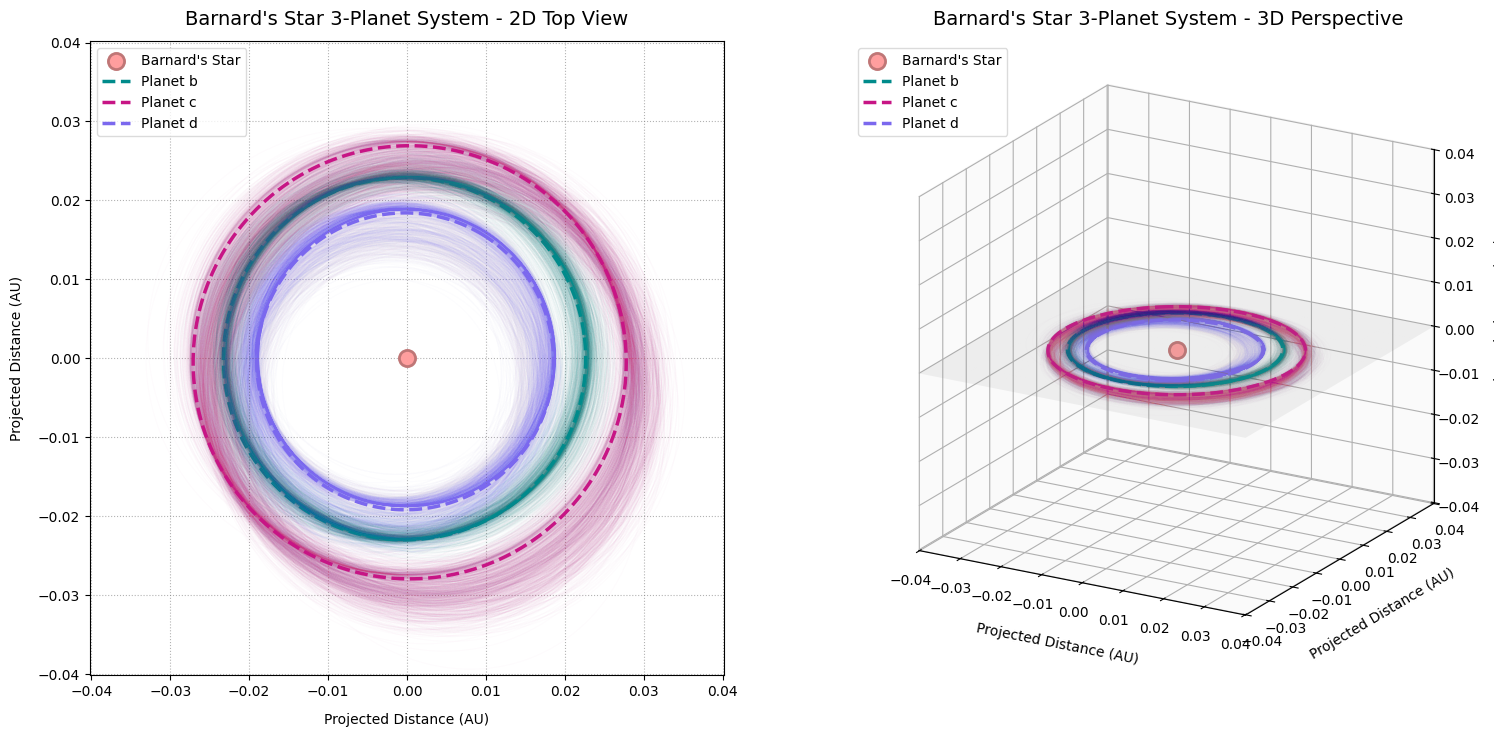

In [11]:
# Set up the figure for side-by-side plotting
fig = plt.figure(figsize=(18, 9), facecolor='white')
ax2d = fig.add_subplot(121, facecolor='white')
ax3d = fig.add_subplot(122, projection='3d', facecolor='white')

# Plot the system clouds
system_3p.plot_system(
    ax=[ax2d, ax3d],
    dimension='both',
    alpha_2d=0.015,
    alpha_3d=0.008,
    show_reference_plane=True
)

ax2d.set_title("Barnard's Star 3-Planet System - 2D Top View", fontsize=14, pad=12)
ax3d.set_title("Barnard's Star 3-Planet System - 3D Perspective", fontsize=14, pad=12)

plt.show()